In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/insurance.csv')

# Encode categorical variables
df_model = df.copy()
df_model['sex'] = LabelEncoder().fit_transform(df_model['sex'])
df_model['smoker'] = LabelEncoder().fit_transform(df_model['smoker'])
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

# Features & Target (log-transformed)
X = df_model.drop('charges', axis=1)
y = np.log1p(df_model['charges'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train set:", X_train.shape)
print("Test set: ", X_test.shape)
print("\nFeatures:", list(X.columns))

Train set: (1070, 8)
Test set:  (268, 8)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [3]:

# Train XGBoost model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions (convert back from log scale)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae = mean_absolute_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)

print("=== Model Performance ===")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE:     ${rmse:,.0f}")
print(f"MAE:      ${mae:,.0f}")

=== Model Performance ===
R2 Score: 0.8480
RMSE:     $4,858
MAE:      $2,402


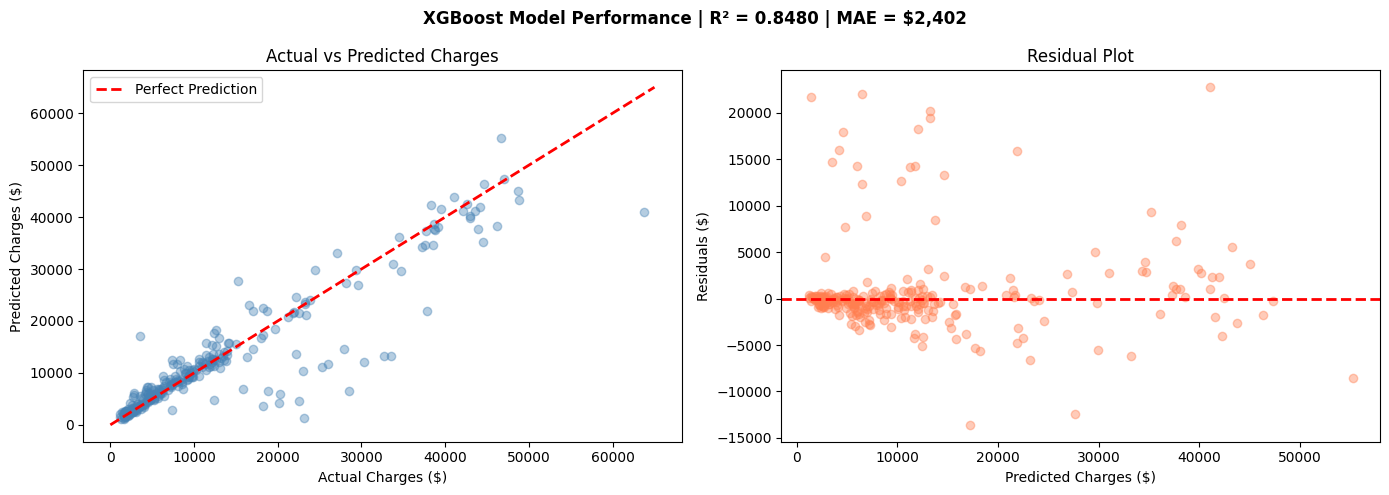

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_orig, y_pred, alpha=0.4, color='steelblue')
axes[0].plot([0, 65000], [0, 65000], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].set_title('Actual vs Predicted Charges')
axes[0].legend()

# Residuals
residuals = y_test_orig - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

plt.suptitle(f'XGBoost Model Performance | R² = {r2:.4f} | MAE = ${mae:,.0f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:

import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/xgboost_model.joblib')
joblib.dump(X_train.columns.tolist(), '../models/feature_names.joblib')

print("Model saved successfully!")
print(f"Features: {X_train.columns.tolist()}")

Model saved successfully!
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
